# Notebook Overview
Please note: This notebook cannot be run on Google Colab because it uses the tkinter library, which requires screen access and user interaction (features not supported in Colab). Please run this notebook locally using Jupyter Notebook.

This notebook contains only the final model: Lucas-Kanade tracking with manual re-detection. 

It also produces the video of the tracking, a plot of the nose temperature tracked, and a csv file containing the frame and nose temperature for each frame from the video.

# Imports and pre-processing steps

In [1]:
import cv2
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import pandas as pd
from skimage import exposure
from skimage.restoration import inpaint
from skimage.restoration import inpaint_biharmonic

from PIL import Image, ImageTk
import tkinter as tk
from tkinter import filedialog

import glob
import os


# Temperature Inpainting 

In [2]:
#Temperature thresholding and biharmonic inpainting method
#used for a single frame
def inpaint_biharmonic_csv(csv_img):
  data = pd.read_csv(csv_img, header=None)
  thermal_image = data.to_numpy()
  lower_threshold = 24
  upper_threshold = 28

  #Creating mask of fence: where the temperature is within the threshold will be white
  fence_mask = (thermal_image >= lower_threshold) & (thermal_image <= upper_threshold)

  #Dilating that fence-mask + Normalise:
  fence_mask = fence_mask.astype(np.uint8) * 255
  kernel = np.ones((3, 3))
  dilated_mask_temp = cv2.dilate(fence_mask, kernel, iterations=3)
  #Inpainting
  inpainted_image_temp = inpaint.inpaint_biharmonic(thermal_image, dilated_mask_temp )
  #Normalise inpaint (Biharmonic output ranges in temp. range)
  inpainted_scaled = cv2.normalize(inpainted_image_temp, None, 0, 255, cv2.NORM_MINMAX)
  inpainted_scaled = inpainted_scaled.astype(np.uint8)

  return inpainted_scaled

In [3]:
#Get coordinates of point clicked by the users
#Works so that only will take the first click you make
#store them in selected_coordinates
#return's the x and y coordinates of the selected point (as tuple)

def get_clicked_coordinates(image):
    #Check to make image into Numpy array 
    if isinstance(image, np.ndarray):
        image = np.clip(image, 0, 255).astype(np.uint8)  
        image = Image.fromarray(image)

    #To store coordinates
    selected_coordinates = {"x": None, "y": None}

    #Create Tkinter Object
    window = tk.Tk()
    window.title("Click Once to Select a Point & Close Window")

    frame = tk.Frame(window)
    frame.pack(fill=tk.BOTH, expand=tk.YES)

    canvas = tk.Canvas(frame, width=image.width, height=image.height)
    canvas.pack(fill=tk.BOTH, expand=tk.YES)

    tk_image = ImageTk.PhotoImage(image)
    canvas.create_image(0, 0, anchor=tk.NW, image=tk_image)

    #Capture's only the first click function
    def get_coordinates(event):
        #Only stores first coordinates that were clicked
        if selected_coordinates["x"] is None and selected_coordinates["y"] is None: 
            selected_coordinates["x"] = event.x
            selected_coordinates["y"] = event.y

            #Shows coordinates selected
            #Horizontal line
            canvas.create_line(event.x - 10, event.y, event.x + 10, event.y, fill="red", width=2)
            #Vertical line  
            canvas.create_line(event.x, event.y - 10, event.x, event.y + 10, fill="red", width=2)  
            
            print(f"Selected Coordinates: ({event.x}, {event.y})")

    #When click anywhere on canvas, it will trigger the get_coordinate function
    #to store the coordinates
    canvas.bind("<Button-1>", get_coordinates)

    #User has to closer the window (had issue if done automatic)
    window.mainloop()

    if selected_coordinates["x"] is not None and selected_coordinates["y"] is not None:
        return (selected_coordinates["x"], selected_coordinates["y"])
    else:
        print("No point selected.")
        return None


# Manual Re-detection

Runs Lucas-kanade and stops if the error is too high (error_threshold represents this error).
When error is too high, a window prompt will appear, the user will click the nose center and tracking will resume. 

Adjust error_threshold variable to adjust how much manual intervention:
* Higher threshold means less manual intervention but increases chance of mis-aligned tracking
* Lower threshold means more manual intervention (too low and it's no longer automatic)

Other things the code does: it is storing all the minium and maximum values for each frame. Since we are normalising each frame independently, when we then exact the temperature values from the tracking (undo normalisation), to get the original temperatures back we need to have the original min max values. The alternative approach would be global normalisation (not implemented here).

In [10]:
#csv_folder_path needs to have the name of the folder where the frames are stored
#There are 3 examples to use:
#"example_difficult"
#"example_1"
#"example_2"
csv_folder_path= "example_difficult"

csv_files = sorted(glob.glob(os.path.join(csv_folder_path, '*.csv')))
if len(csv_files) == 0:
    #incase folder doesn't exist error
    raise Exception("No CSV files found in the specified folder.")

#Name of path where the output video will be
#In this case desktop and will be called temp_Tracking_test
output_video_path = os.path.join(os.path.expanduser("~"), "Desktop", "temp_Tracking_test_3.mp4") 

#First frame needs to be inpainted
first_csv = csv_files[0]
#Inpainting it (method inpaint_biharmonic_csv takes image, detects fence, inpaints )
first_frame_inpaint = inpaint_biharmonic_csv(first_csv)
#extract the frame's height and width
frame_height, frame_width = first_frame_inpaint.shape

#VideoWriter is used to put frames back together
#30 Frames per second
#Format: mp4
fps = 30
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
#Stating the paramters: where it outputs, using VideoWriter, 30 frames per second, width and height of video
out = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height))

image = Image.fromarray(first_frame_inpaint)
#Manually getting this nose coordinates for the first frame, calls get clicked coordinates
x,y = get_clicked_coordinates(image)
#stores coordinates in inital point
initial_point = np.array([[x,y]], dtype=np.float32) 

#Reshaping for LK algorithm
p0 = initial_point.reshape(-1, 1, 2)
prev_gray = first_frame_inpaint.copy()

#Annotate the first frame with the tracking point
#To annoate nose ciricle in a colour, must convert grayscale to coloured
first_frame_bgr = cv2.cvtColor(first_frame_inpaint, cv2.COLOR_GRAY2BGR)
#making the circle/eclipse ontop of the pixel, Green (255) and only border (+1), if filled (-1), can adjust size thickness
#1 is good but bigger for figures is better
cv2.circle(first_frame_bgr, (int(initial_point[0, 0]), int(initial_point[0, 1])), 10, (0, 255, 0), 2)
frame_idx = 0
cv2.putText(first_frame_bgr, f"Frame: {frame_idx}", (10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
#Add first frame to video sequence output
out.write(first_frame_bgr)

#Lucas–Kanade Optical Flow Parameters
lk_params = dict(
    winSize  = (15, 15),
    maxLevel = 2,
    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
)



############################################################################ ERROR THRESHOLD THAT CAN BE ADJUSTED #########################################
error_threshold = 5 
#tracked_coordinates is a list that tracks all nose coordinates for later temperature plotting
tracked_coordinates = [(int(initial_point[0, 0]), int(initial_point[0, 1]))] 
#Stores inapitned nose values for those coordinates for later temp. plotting
pixel_values = [first_frame_inpaint[int(initial_point[0, 1]), int(initial_point[0, 0])]]

#For each frame after the first one
for csv_file in csv_files[1:]:
    # Inpaint current frame
    inpainted_frame = inpaint_biharmonic_csv(csv_file)
    frame_gray = inpainted_frame.copy()

    #Compute optical flow from prev_gray to current frame
    p1, st, err = cv2.calcOpticalFlowPyrLK(prev_gray, frame_gray, p0, None, **lk_params)

    #Check if tracking failed or error exceeds threshold
    if p1 is None or st[0][0] == 0 or (err is not None and err[0][0] > error_threshold):
        print(f"Tracking lost at frame index {frame_idx}.")
        print(f"Tracking lost or error ({err[0][0] if err is not None else 'N/A'}) exceeded threshold at frame index {frame_idx}.")
        print("Please re-detect the nose by clicking on the image.")
        
        #If residual eror is > 5 then re-call get_clicked_coordinates function to manually re-initalise the points
        image_for_click = Image.fromarray(frame_gray)
        new_coords = get_clicked_coordinates(image_for_click)
        re_point = np.array([[new_coords]], dtype=np.float32)
        new_point = re_point.copy()
    else:
        #If tracking was good, then keep the point tracked: (no need for update)
        new_point = p1 
    
    #Draw the new point on the frame
    pt = new_point[0][0] 
    #Store coordinates
    tracked_coordinates.append((int(pt[0]), int(pt[1])))
    #Store inpainted nose value at those coordinates
    pixel_value = frame_gray[int(pt[1]), int(pt[0])]
    pixel_values.append(pixel_value)


    frame_colour = cv2.cvtColor(inpainted_frame, cv2.COLOR_GRAY2BGR)
    cv2.circle(frame_colour, (int(pt[0]), int(pt[1])), 10, (0, 255, 0), 1)
    frame_idx += 1
    cv2.putText(frame_colour, f"Frame: {frame_idx}", (10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

    out.write(frame_colour)

    #Update the previous frame and tracking point for the next iteration
    prev_gray = frame_gray.copy()
    p0 = new_point.copy()
    


#Release the video
out.release()
print("Tracking complete. Output video saved at:", output_video_path)


Selected Coordinates: (270, 146)
Tracking lost at frame index 5.
Tracking lost or error (7.920833110809326) exceeded threshold at frame index 5.
Please re-detect the nose by clicking on the image.
Selected Coordinates: (283, 148)
Tracking lost at frame index 6.
Tracking lost or error (5.2934722900390625) exceeded threshold at frame index 6.
Please re-detect the nose by clicking on the image.
Selected Coordinates: (288, 153)
Tracking lost at frame index 17.
Tracking lost or error (6.52097225189209) exceeded threshold at frame index 17.
Please re-detect the nose by clicking on the image.
Selected Coordinates: (303, 154)
Tracking lost at frame index 18.
Tracking lost or error (5.78000020980835) exceeded threshold at frame index 18.
Please re-detect the nose by clicking on the image.
Selected Coordinates: (298, 159)
Tracking lost at frame index 19.
Tracking lost or error (6.268750190734863) exceeded threshold at frame index 19.
Please re-detect the nose by clicking on the image.
Selected C

# Plotting Temperatures

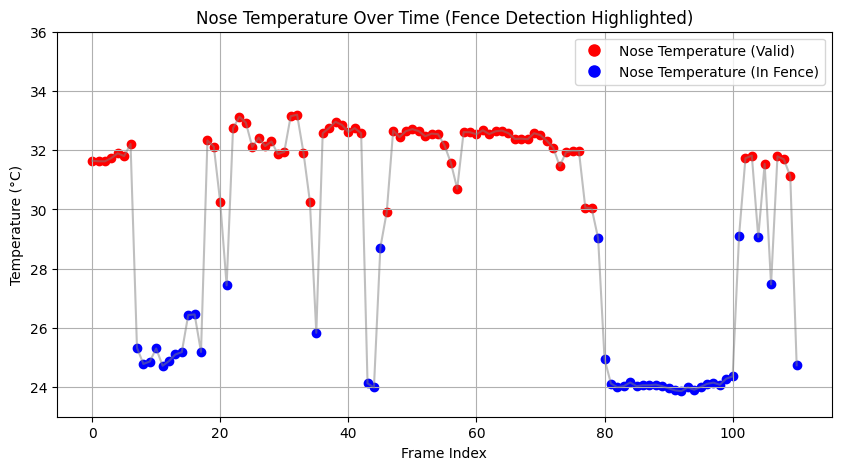

In [11]:
###############################     Plotting the real nose temperatures   (code also produces csv file with nose temperatures per frame)  ######################
####PLEASE NOTE :
#upper_threshold is an arbitrary threshold to distinguish between fenced vs non-fenced areas.
#Further research is required to accurately determine which temperatures are part of the the fence and which are not.
#For now this only acts for illustrative purposes

upper_threshold = 29.9

real_temperatures = []
colors = []

#For each csv frame in csv file doler
for i, csv_file in enumerate(csv_files[:len(tracked_coordinates)]):
    #Load csv frame
    thermal_frame = np.loadtxt(csv_file, delimiter=",") 
    #load it's corresponding tracked coordinates 
    x, y = tracked_coordinates[i]  
    #Extract the real temperature at that coordinate
    temp_value = thermal_frame[y, x]  
    #add that to the list
    real_temperatures.append(temp_value)

    #Assing color: blue if in fence range, red otherwise
    if temp_value <= upper_threshold:
        colors.append('b')  
    else:
        colors.append('r') 

#to output csv file with nose temperature
with open("nose_temperatures.csv", mode="w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Frame", "Temperature"])
    for i, temp in enumerate(real_temperatures):
        writer.writerow([i, temp])

plt.figure(figsize=(10, 5))
#Assigning each nose point it's corresponding colour (depending of if it met threshold or not)
for i in range(len(real_temperatures)):
    plt.scatter(i, real_temperatures[i], color=colors[i])

#Connect each point with gray line
plt.plot(range(len(real_temperatures)), real_temperatures, linestyle='-', color='gray', alpha=0.5)

#Legend
red_marker = mlines.Line2D([], [], color='r', marker='o', linestyle='None', markersize=8, label="Nose Temperature (Valid)")
blue_marker = mlines.Line2D([], [], color='b', marker='o', linestyle='None', markersize=8, label="Nose Temperature (In Fence)")

plt.ylim(23, 36)
plt.xlabel("Frame Index")
plt.ylabel("Temperature (°C)")
plt.title("Nose Temperature Over Time (Fence Detection Highlighted)")
plt.legend(handles=[red_marker, blue_marker]) 
plt.grid()
plt.savefig("nose_temperature_plot.png", dpi=600, bbox_inches='tight')
plt.show()


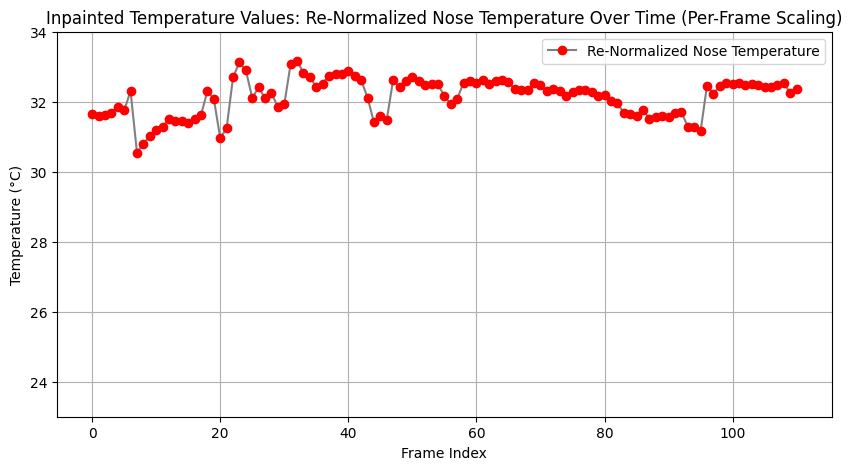

In [12]:
###############################     Plotting the inpainted nose temperatures     ######################


#Test: number of pixel values = the number of frames
if len(pixel_values) != len(csv_files):
    raise Exception(f"Mismatch: {len(pixel_values)} pixel values vs {len(csv_files)} frames.")

#List to store re-normalized temperature values
inpainted_Temps = []

for i, csv_file in enumerate(csv_files):
    #For each frame in csv file
    thermal_frame = np.loadtxt(csv_file, delimiter=",")
    #Get it original temperature min and max
    temp_min = np.min(thermal_frame)
    temp_max = np.max(thermal_frame)

    #Get the nose inpainted value
    grayscale_pixel = pixel_values[i]

    #Reverse normalization: Convert grayscale (0-255) back to temperature for that nose inpainted value
    temperatu_value = ((grayscale_pixel / 255) * (temp_max - temp_min)) + temp_min

    #Store the re-normalized temperature value
    inpainted_Temps.append(temperatu_value)


plt.figure(figsize=(10, 5))
plt.plot(range(len(inpainted_Temps)), inpainted_Temps, marker='o', linestyle='-', color='gray', markeredgecolor='red', markerfacecolor ="red" ,label="Re-Normalized Nose Temperature")

plt.ylim(23, 34) 
plt.xlabel("Frame Index")
plt.ylabel("Temperature (°C)")
plt.title("Inpainted Temperature Values: Re-Normalized Nose Temperature Over Time (Per-Frame Scaling)")
plt.legend()
plt.grid()
plt.savefig("Inpainted_values_plot.png", dpi=600, bbox_inches='tight')
plt.show()

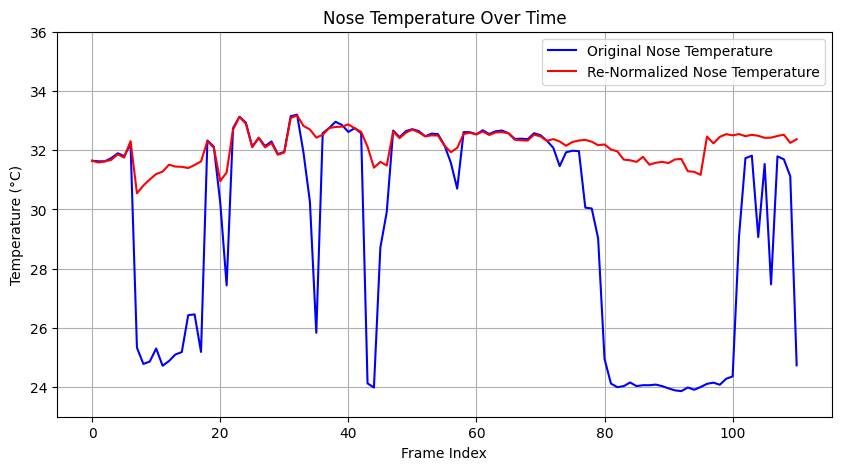

In [13]:
###############################     Plotting the both the real and inpainted nose temperatures  (one ontop of the other)  ######################

inpainted_Temps = []
real_temperatures = []

for i, csv_file in enumerate(csv_files[:len(tracked_coordinates)]):
    #for each frame

    #get real nose value
    thermal_frame = np.loadtxt(csv_file, delimiter=",") 
    x, y = tracked_coordinates[i] 
    temp_value = thermal_frame[y, x] 
    real_temperatures.append(temp_value)

    #Re-normalise inpainted value
    temp_min = np.min(thermal_frame)
    temp_max = np.max(thermal_frame)
    grayscale_pixel = pixel_values[i]
    temperature_value = ((grayscale_pixel / 255) * (temp_max - temp_min)) + temp_min
    inpainted_Temps.append(temperature_value)

#Plot
plt.figure(figsize=(10, 5))
plt.plot(range(len(real_temperatures)), real_temperatures, linestyle='-', color='blue', label='Original Nose Temperature')
plt.plot(range(len(inpainted_Temps)), inpainted_Temps, linestyle='-', color='red', label='Re-Normalized Nose Temperature')

plt.ylim(23, 36)
plt.xlabel("Frame Index")
plt.ylabel("Temperature (°C)")
plt.title("Nose Temperature Over Time")
plt.legend()
plt.grid()
plt.savefig("Super-imposed-plot.png", dpi=600, bbox_inches='tight')
plt.show()
